## Importando bibliotecas

In [24]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

## Gerando dados mockados

In [25]:
# Parâmetros
np.random.seed(42)
turnos = ['Manhã', 'Tarde', 'Noite']
tipos_materiais = ['Plástico', 'Metal', 'Papel', 'Vidro']

# Gerar dados mockados para 30 dias
data_inicial = datetime(2025, 3, 1)
dias = 30
linhas = []

for dia in range(dias):
    for turno in turnos:
        for _ in range(3):  # 3 lotes por turno
            data = data_inicial + timedelta(days=dia)
            tipo_material = random.choice(tipos_materiais)
            total_processado = np.random.randint(100, 300)
            corretamente_separado = int(total_processado * np.random.uniform(0.85, 0.99))
            mal_separado = total_processado - corretamente_separado
            reciclavel_kg = total_processado * np.random.uniform(0.8, 1.2)
            tempo_total_processamento = np.random.uniform(200, 800)  # segundos
            material_descartado_indev = np.random.randint(0, 10)
            tempo_operacional = np.random.uniform(50, 60)  # minutos
            tempo_total_disp = 60  # minutos
            acertos_algoritmo = int(total_processado * np.random.uniform(0.88, 0.98))
            
            linhas.append({
                'data': data,
                'turno': turno,
                'tipo_material': tipo_material,
                'total_processado': total_processado,
                'corretamente_separado': corretamente_separado,
                'mal_separado': mal_separado,
                'reciclavel_kg': reciclavel_kg,
                'tempo_total_processamento': tempo_total_processamento,
                'material_descartado_indev': material_descartado_indev,
                'tempo_operacional': tempo_operacional,
                'tempo_total_disponivel': tempo_total_disp,
                'acertos_algoritmo': acertos_algoritmo
            })
            
# Criar DataFrame
df = pd.DataFrame(linhas)

## Visualizando DataFrame

In [26]:
df = pd.DataFrame(linhas)

df = df.round(2)

df.head()

,data,turno,tipo_material,total_processado,corretamente_separado,mal_separado,reciclavel_kg,tempo_total_processamento,material_descartado_indev,tempo_operacional,tempo_total_disponivel,acertos_algoritmo
0,2025-03-01,Manhã,Papel,202,194,8,176.42,667.81,4,51.56,60,180
1,2025-03-01,Manhã,Plástico,174,159,15,162.43,285.72,2,50.21,60,169
2,2025-03-01,Manhã,Papel,257,226,31,224.29,310.04,9,55.25,60,237
3,2025-03-01,Tarde,Vidro,148,136,12,142.07,228.00,2,53.82,60,144
4,2025-03-01,Tarde,Metal,230,223,7,246.59,470.30,1,59.49,60,224


# Criando DataFrame com os KPI's

In [27]:
kpi_df = pd.DataFrame({
    'data': df['data'],
    'turno': df['turno'],
    'tipo_material': df['tipo_material'],
    'eficiencia_separacao': (df['corretamente_separado'] / df['total_processado']) * 100,
    'taxa_erro': (df['mal_separado'] / df['total_processado']) * 100,
    'produtividade_linha': df['reciclavel_kg'],  
    'tempo_medio_processamento': df['tempo_total_processamento'] / df['total_processado'],
    'indice_desperdicio': (df['material_descartado_indev'] / df['total_processado']) * 100,
    'disponibilidade_sistema': (df['tempo_operacional'] / df['tempo_total_disponivel']) * 100,
    'precisao_algoritmo': (df['acertos_algoritmo'] / df['total_processado']) * 100
})


In [28]:
# Arredondando para 2 casas decimais
kpi_df = kpi_df.round(2)

kpi_df.head()

,data,turno,tipo_material,eficiencia_separacao,taxa_erro,produtividade_linha,tempo_medio_processamento,indice_desperdicio,disponibilidade_sistema,precisao_algoritmo
0,2025-03-01,Manhã,Papel,96.04,3.96,176.42,3.31,1.98,85.93,89.11
1,2025-03-01,Manhã,Plástico,91.38,8.62,162.43,1.64,1.15,83.68,97.13
2,2025-03-01,Manhã,Papel,87.94,12.06,224.29,1.21,3.50,92.08,92.22
3,2025-03-01,Tarde,Vidro,91.89,8.11,142.07,1.54,1.35,89.70,97.30
4,2025-03-01,Tarde,Metal,96.96,3.04,246.59,2.04,0.43,99.15,97.39


## Visualização dos dados

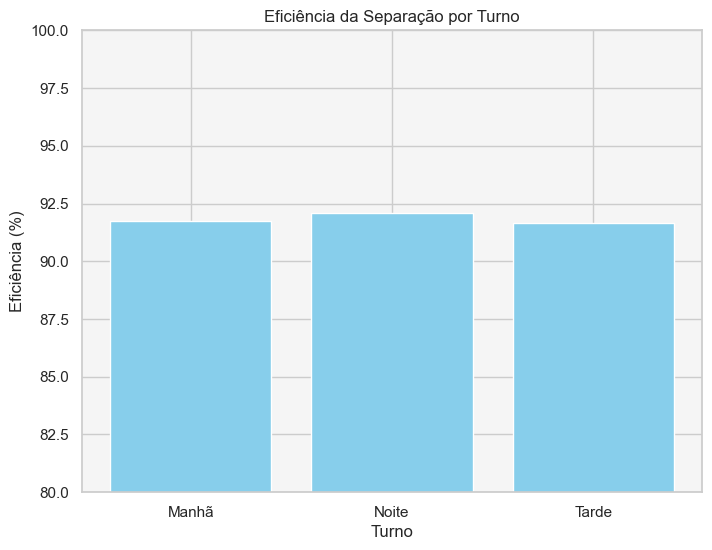

In [84]:
media_eficiencia_turno = kpi_df.groupby('turno')['eficiencia_separacao'].mean()

plt.figure(figsize=(8, 6))
plt.bar(media_eficiencia_turno.index, media_eficiencia_turno.values, color='skyblue')
plt.gca().set_facecolor('whitesmoke')
plt.title('Eficiência da Separação por Turno')
plt.xlabel('Turno')
plt.ylabel('Eficiência (%)')
plt.ylim(80, 100)
plt.show()


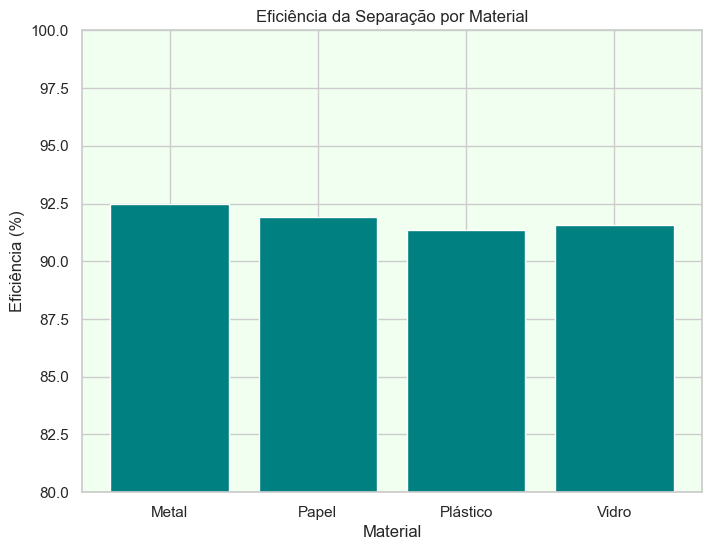

In [85]:

media_eficiencia = kpi_df.groupby('tipo_material')['eficiencia_separacao'].mean()

plt.figure(figsize=(8, 6))
plt.bar(media_eficiencia.index, media_eficiencia.values, color='teal')
plt.gca().set_facecolor('honeydew')
plt.ylim(80, 100)
plt.title('Eficiência da Separação por Material')
plt.xlabel('Material')
plt.ylabel('Eficiência (%)')
plt.show()


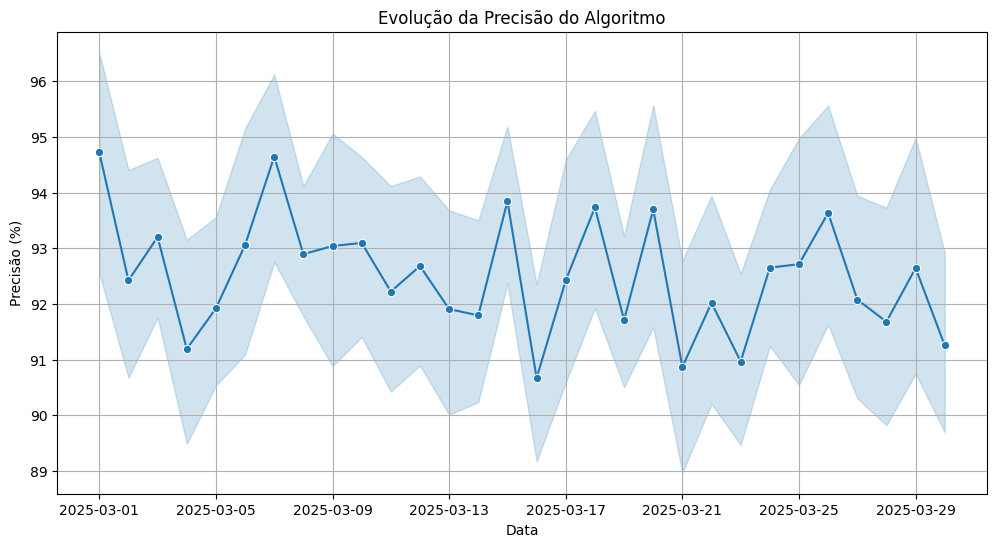

In [40]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=kpi_df, x='data', y='precisao_algoritmo', marker='o')
plt.title('Evolução da Precisão do Algoritmo')
plt.xlabel('Data')
plt.ylabel('Precisão (%)')
plt.grid(True)
plt.show()


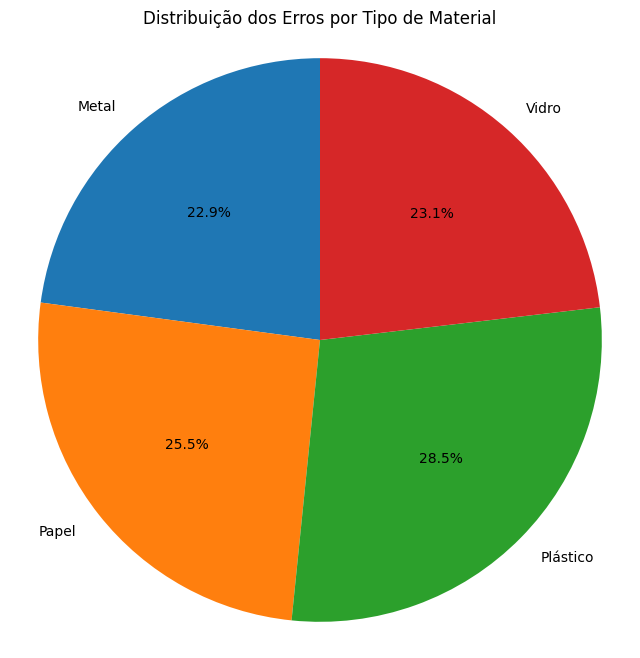

In [44]:
erros_por_material = df.groupby('tipo_material')['mal_separado'].sum()

plt.figure(figsize=(8, 8))
plt.pie(erros_por_material, labels=erros_por_material.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição dos Erros por Tipo de Material')
plt.axis('equal') 
plt.show()


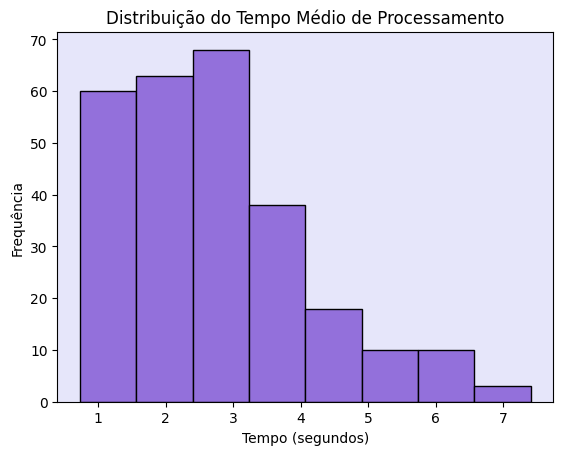

In [ ]:
plt.hist(kpi_df['tempo_medio_processamento'], bins=8, color='mediumpurple', edgecolor='black')
plt.gca().set_facecolor('lavender')
plt.title('Distribuição do Tempo Médio de Processamento')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Frequência')
plt.show()


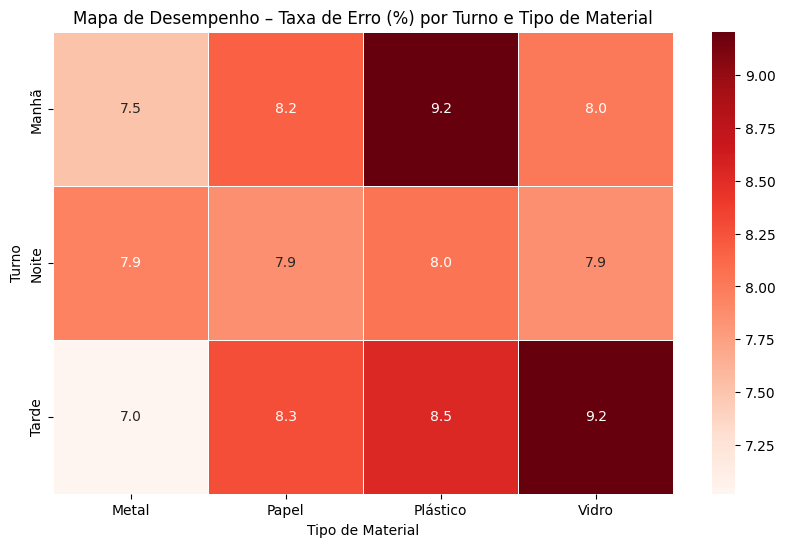

In [62]:
heatmap_erro = kpi_df.groupby(['turno', 'tipo_material'])['taxa_erro'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_erro, annot=True, fmt=".1f", cmap="Reds", linewidths=0.5)
plt.title('Mapa de Desempenho – Taxa de Erro (%) por Turno e Tipo de Material')
plt.xlabel('Tipo de Material')
plt.ylabel('Turno')
plt.show()


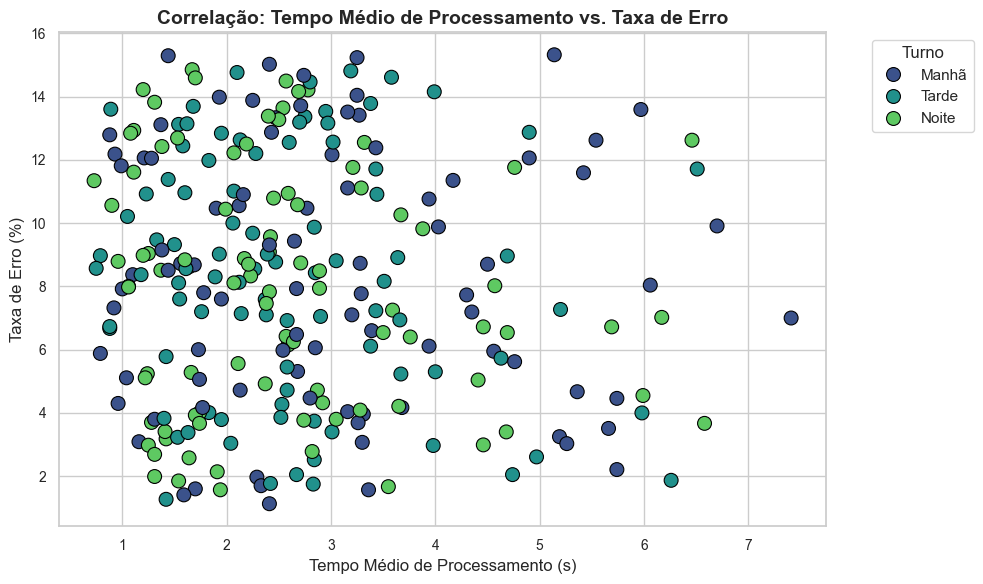

In [93]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.scatterplot(
    data=kpi_df,
    x='tempo_medio_processamento',
    y='taxa_erro',
    hue='turno',                 
    palette='viridis',
    s=100,
    edgecolor='black'
)

plt.title('Correlação: Tempo Médio de Processamento vs. Taxa de Erro', fontsize=14, weight='bold')
plt.xlabel('Tempo Médio de Processamento (s)', fontsize=12)
plt.ylabel('Taxa de Erro (%)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Turno')
plt.tight_layout()
plt.show()
